In [1]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
%matplotlib inline

In [4]:
sns.set_theme(style = 'darkgrid')

#### Calculating the top 10 prescribed anti-depressants across the whole time frame, sorted from biggest from smallest.

In [5]:
pca_regional_drug_summary_df = pd.read_csv("BSA_ODP_PCA_REGIONAL_DRUG_SUMMARY.csv")

In [6]:
df_q1 = pca_regional_drug_summary_df.groupby(by = 'BNF_CHEMICAL_SUBSTANCE', as_index=False)["ITEMS"].sum().sort_values("ITEMS", ascending=False).head(10)
# display(df_q1)

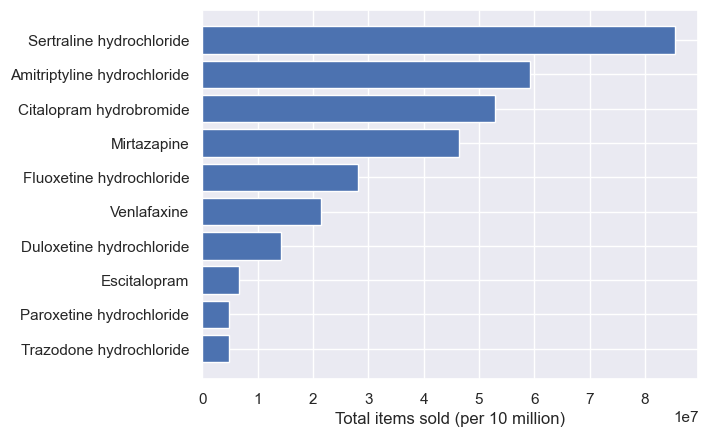

In [7]:
plt.barh(df_q1['BNF_CHEMICAL_SUBSTANCE'], df_q1['ITEMS'])
plt.xlabel('Total items sold (per 10 million)')
plt.gca().invert_yaxis()
plt.show()

#### Top 5 most prescribed drugs in 2024, arranged in order.

In [8]:
df_2_q1 = pca_regional_drug_summary_df[pca_regional_drug_summary_df["YEAR"] == 2024]
df_2_q1 = df_2_q1.groupby(by = "BNF_CHEMICAL_SUBSTANCE", as_index=False)["ITEMS"].sum().sort_values("ITEMS", ascending=False).head(5)
df_2_q1 = df_2_q1.sort_values("ITEMS", ascending=True)
# display(df_2_q1)

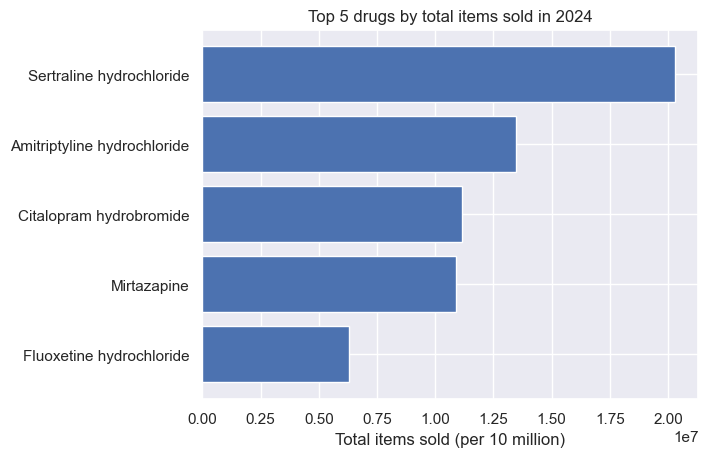

In [9]:
plt.barh(df_2_q1["BNF_CHEMICAL_SUBSTANCE"], df_2_q1["ITEMS"])
plt.xlabel("Total items sold (per 10 million)")
plt.title("Top 5 drugs by total items sold in 2024")
plt.show()

#### Creating a monthly line chart showing total national prescribing cost

In [10]:
# pca_regional_drug_summary_df.head()

In [11]:
df_3_q1 = pca_regional_drug_summary_df.groupby(by = "YEAR_MONTH", as_index=False)["COST"].sum()
# df_3_q1.head()

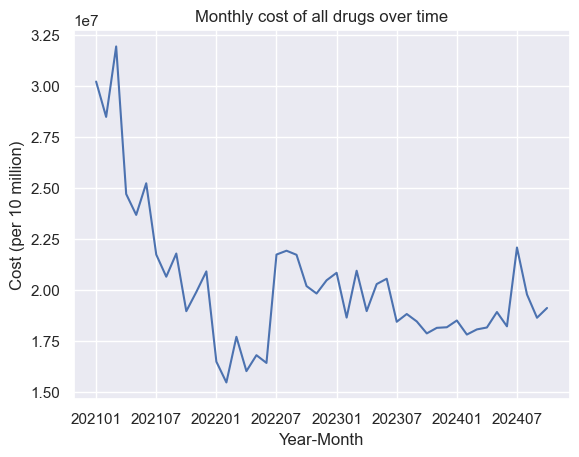

In [12]:
plt.plot(np.arange(len(df_3_q1)), df_3_q1["COST"])
plt.xticks(ticks = np.arange(0, len(df_3_q1))[::6], labels = df_3_q1["YEAR_MONTH"].values[::6])
plt.xlabel("Year-Month")
plt.ylabel("Cost (per 10 million)")
plt.title("Monthly cost of all drugs over time")
plt.show()

#### *Annual* summary statistics, for the min, Q1, median, Q3 and maximum national monthly prescribing cost (i.e. all drugs across all regions)


In [13]:
years = pca_regional_drug_summary_df["YEAR"].unique()
years = np.sort(years)
# years

In [14]:
stat_dict = {}
for year in years:
    df_x = pca_regional_drug_summary_df[pca_regional_drug_summary_df["YEAR"] == year]
    df_x = df_x.groupby(by = "YEAR_MONTH", as_index=False)["COST"].sum()
    print(f"For year {year}:")
    min_cost = df_x["COST"].min()
    print(f"    Minimum cost: {min_cost}")
    q1_cost = df_x["COST"].quantile(0.25)
    print(f"    Q1 cost: {q1_cost}")
    median_cost = df_x["COST"].median()
    print(f"    Median cost: {median_cost}")
    q3_cost = df_x["COST"].quantile(0.75)
    print(f"    Q3 cost: {q3_cost}")
    max_cost = df_x["COST"].max()
    print(f"    Maximum cost: {max_cost}")
    stat_dict[year] = [min_cost, q1_cost, median_cost, q3_cost, max_cost]

For year 2021:
    Minimum cost: 18949756.25
    Q1 cost: 20835485.0625
    Median cost: 22724239.54
    Q3 cost: 26036579.7275
    Maximum cost: 31933609.64
For year 2022:
    Minimum cost: 15453991.47
    Q1 cost: 16458372.8425
    Median cost: 18754196.950000003
    Q3 cost: 20776869.8525
    Maximum cost: 21914896.72
For year 2023:
    Minimum cost: 17859075.18
    Q1 cost: 18362788.4525
    Median cost: 18722910.305
    Q3 cost: 20344159.9175
    Maximum cost: 20934041.830000002
For year 2024:
    Minimum cost: 17802904.89
    Q1 cost: 18163828.4825
    Median cost: 18560027.0
    Q3 cost: 19056283.625
    Maximum cost: 22071625.09


#### Creating a grouped boxplot that shows the above information (4 boxplots, 1 per year)

In [15]:
ann_stats = {}
for year in years:
    df_x = pca_regional_drug_summary_df[pca_regional_drug_summary_df["YEAR"] == year]
    df_x = df_x.groupby(by = "YEAR_MONTH", as_index=False)["COST"].sum()
    ann_stats[year] = df_x["COST"]

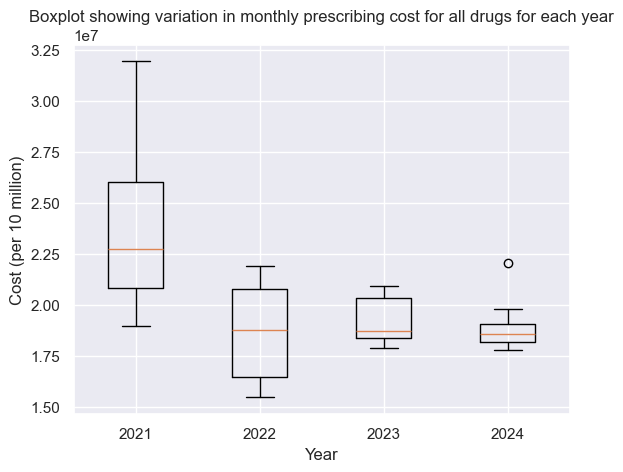

In [16]:
plt.boxplot(ann_stats.values(), tick_labels = ann_stats.keys())
plt.xlabel("Year")
plt.ylabel("Cost (per 10 million)")
plt.title("Boxplot showing variation in monthly prescribing cost for all drugs for each year")
plt.show()

#### Calculating the annual *mean* monthly total national prescribing cost and display in a vertical barchart

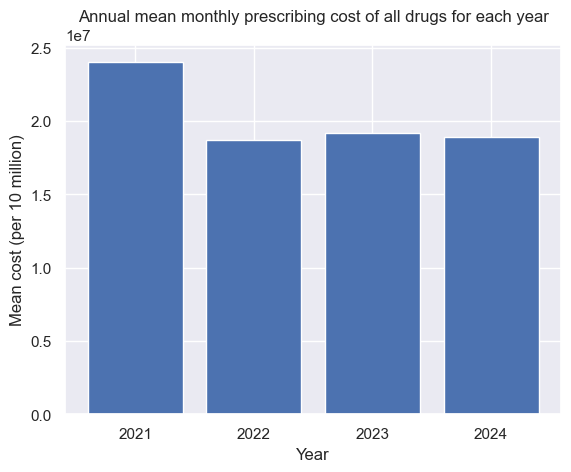

In [17]:
ann_mean = [(year, x.mean()) for (year, x) in (ann_stats.items())]
plt.bar(np.arange(len(ann_mean)), [y for (x, y) in ann_mean])
plt.xticks(ticks = np.arange(len(ann_mean)), labels = [x for (x, y) in ann_mean])
plt.xlabel("Year")
plt.ylabel("Mean cost (per 10 million)")
plt.title("Annual mean monthly prescribing cost of all drugs for each year")
plt.show()

#### Analysing the trends in annual anti-depressant prescription items sold and cost

    First, we will create a bar chart showing the total annual antidepressant prescribing (items).
    Second, we will create a bar chart that shows the total antidepressant prescribing cost.
    Then, we will describe the trend of each chart and compare the charts against each other.

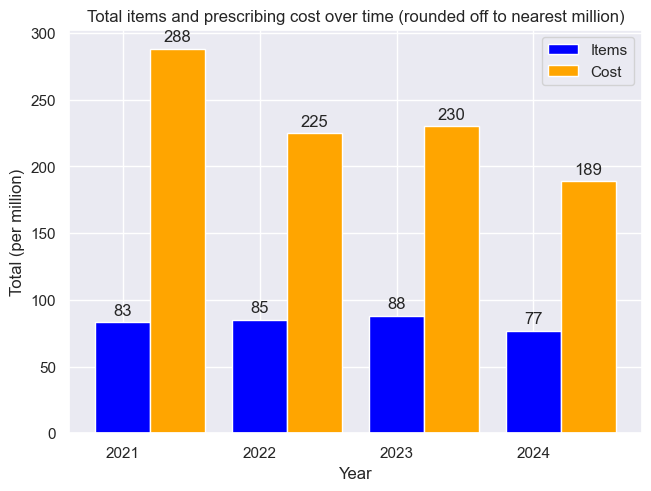

In [18]:
df_items = pca_regional_drug_summary_df.groupby(by = "YEAR", as_index=False)["ITEMS"].sum()
df_items["ITEMS"] = np.round(df_items["ITEMS"]/10**6,0)
df_cost = pca_regional_drug_summary_df.groupby(by = "YEAR", as_index=False)["COST"].sum()
df_cost["COST"] = np.round(df_cost["COST"]/10**6,0)
fig, ax = plt.subplots(layout = "constrained")
r = ax.bar(np.arange(len(df_items)), df_items["ITEMS"], color = "blue", label = "Items", width = 0.4)
ax.bar_label(r, padding=3)
r = ax.bar(np.arange(len(df_cost)) + 0.4, df_cost["COST"], color = "orange", label = "Cost", width = 0.4)
ax.bar_label(r, padding=3)
plt.xticks(ticks = np.arange(len(df_items)), labels = df_items["YEAR"])
plt.xlabel("Year")
plt.ylabel("Total (per million)")
plt.title("Total items and prescribing cost over time (rounded off to nearest million)")
plt.legend()
plt.show()

Since we only have 10 months worth of data for 2024, it is not fair to compare it to other years directly. To make the comparison fare, lets find the mean no. of items and mean cost per month for 2024 and multiply it by 12 to approximate the items and cost consumption for the entire year.

In [19]:
df_items.loc[[3], ["ITEMS"]] = np.round(df_items.loc[[3], ["ITEMS"]]/10*12, 0)
df_cost.loc[[3], ["COST"]] = np.round(df_cost.loc[[3], ["COST"]]/10*12, 0)

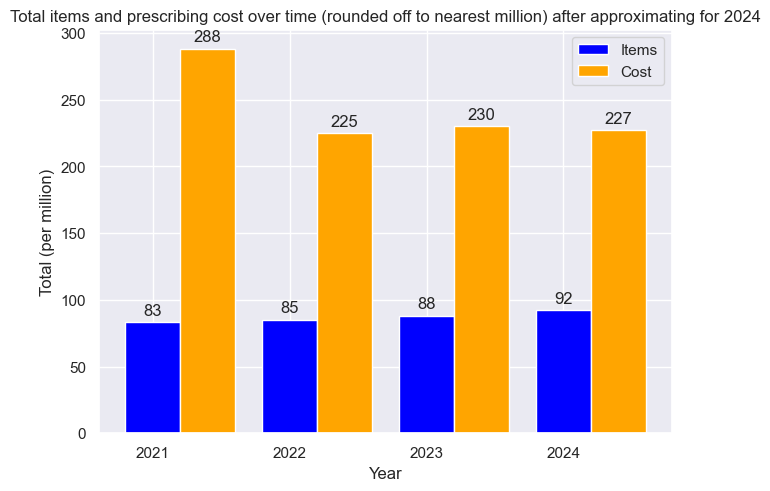

In [20]:
fig, ax = plt.subplots(layout = "constrained")
r = ax.bar(np.arange(len(df_items)), df_items["ITEMS"], color = "blue", label = "Items", width = 0.4)
ax.bar_label(r, padding=3)
r = ax.bar(np.arange(len(df_cost)) + 0.4, df_cost["COST"], color = "orange", label = "Cost", width = 0.4)
ax.bar_label(r, padding=3)
plt.xticks(ticks = np.arange(len(df_items)), labels = df_items["YEAR"])
plt.xlabel("Year")
plt.ylabel("Total (per million)")
plt.title("Total items and prescribing cost over time (rounded off to nearest million) after approximating for 2024")
plt.legend()
plt.show()

From the above chart, we can say that the the total cost is on a decreasing trend from 2021 onwards. The number of items have a slight increasing trend based on the above data. The reason for increase in number of medicines being sold can be due to various reasons, and needs further analysis. One possible reason could be that mental health awareness is increasing, which is leading to more people seeking mental help, which is causing more prescriptions, thus leading to more antidepressant drugs being sold. To confirm this observation, we might want to look at average number of anti-depressant drugs being prescribed per prescription.

Also, from the above graph, we can approximately say that the average price of medicine per item is declining. Let's confirm this observation with another visualisation:

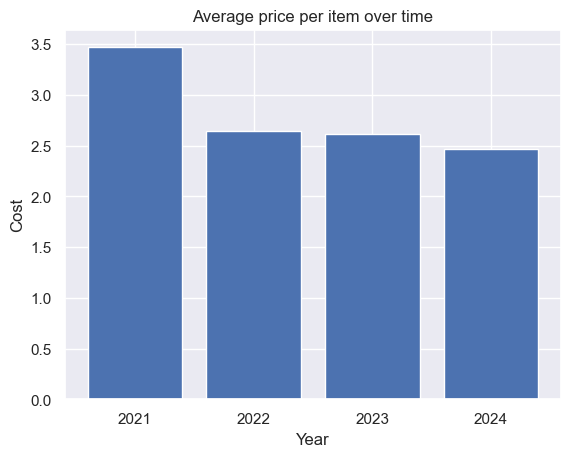

In [21]:
df_price_per_item = df_cost.copy()
df_price_per_item["COST"] = df_cost["COST"]/df_items["ITEMS"]
plt.bar(np.arange(len(df_price_per_item)), df_price_per_item["COST"])
plt.xticks(ticks = np.arange(len(df_price_per_item)), labels = df_price_per_item["YEAR"])
plt.xlabel("Year")
plt.ylabel("Cost")
plt.title("Average price per item over time")
plt.show()

The above observation is confirmed by this barchart which shows that average price per item has been declining over the past 4 years. This is a good stat to see, showing that the price of medicine is not increasing over time, thus making sure that the medicine is affordable.

Two possible reasons for this can be:
1. The average price of anti-depressants has decreased over time (which we will see later is the correct reason).
2. Assuming the prices of the anti-depressant drugs are not changing much, the reason for this trend can be that the prescription of cheaper anti-depressants has increased more proprotion-wise as compared to the prescription of costlier anti-depressants.

#### Analysing the regionwise data for total annual antidepressant prescribed items and cost 
    First, we will create a table showing the total annual antidepressant prescribing per region (items).
    Second, we will create a table showing the annual antidepressant prescribing cost per region.
    Then, we will describe some regional changes and contrasts between 2021 and 2024.

In [22]:
df_region_items = pca_regional_drug_summary_df.pivot_table(index = "YEAR", columns = "REGION_NAME", values = "ITEMS", aggfunc = "sum")
# display(df_region_items)

The above table shows the total annual antidepressant prescribing per region (items). To analyse the changes between the years 2021 and 2024, we create a separate table and visualisation to make the comparison easier.

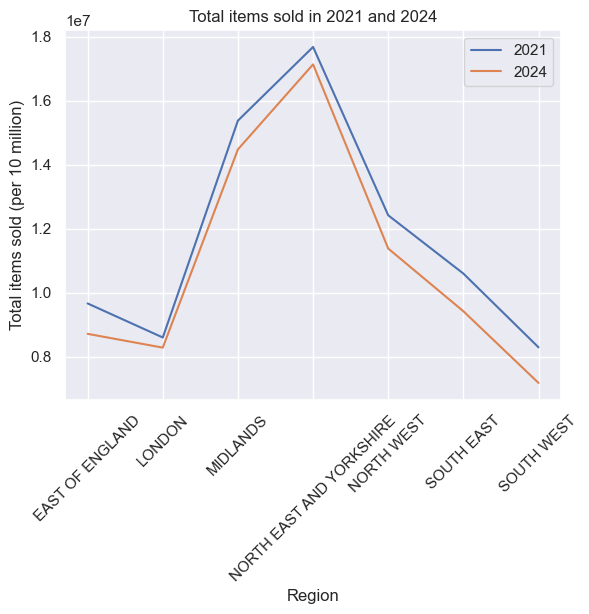

In [23]:
# comparing total items sold in 2021 and 2024
df_region_items_2021 = df_region_items.loc[[2021]]
df_region_items_2024 = df_region_items.loc[[2024]]
df_region_items_comp = pd.DataFrame(index=df_region_items_2021.columns, columns = ["2021", "2024"])
df_region_items_comp["2021"] = df_region_items_2021.values[0]
df_region_items_comp["2024"] = df_region_items_2024.values[0]
df_region_items_comp["diff"] = - df_region_items_comp["2024"] + df_region_items_comp["2021"]
# display(df_region_items_comp)

plt.plot(np.arange(len(df_region_items_comp)), df_region_items_comp["2021"], label = "2021")
plt.plot(np.arange(len(df_region_items_comp)), df_region_items_comp["2024"], label = "2024")
# plt.plot(np.arange(len(df_region_items_comp)), df_region_items_comp["diff"], label = "Difference")
plt.xticks(ticks = np.arange(len(df_region_items_comp)), labels = df_region_items_comp.index, rotation = 45)
plt.xlabel("Region")
plt.ylabel("Total items sold (per 10 million)")
plt.title("Total items sold in 2021 and 2024")
plt.legend()
plt.show()

The above chart shows the trends of total annual antidepressant items sold during 2021 and 2024. We can make the following observations from it:

1. All regions have experienced a decrease in the number of items sold.
2. The lowest number of antidepressents sold in 2021 were in the South West region, which is also true for 2024.
3. The highest number of antidepressents sold in 2021 were in the North East and Yorkshire region, which is also true for 2024.
4. The largest decrease in the number of items sold is in South East region, and the smallest decrease is in the London region.

In [24]:
df_region_cost = pca_regional_drug_summary_df.pivot_table(index = "YEAR", columns = "REGION_NAME", values = "COST", aggfunc = "sum")
# display(df_region_cost)

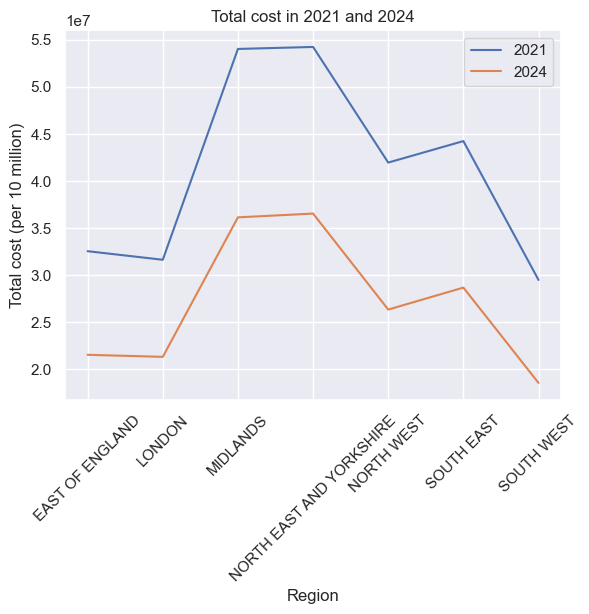

In [25]:
# comparing cost of medication in  2021 and 2024
df_region_cost_2021 = df_region_cost.loc[[2021]]
df_region_cost_2024 = df_region_cost.loc[[2024]]
df_region_cost_comp = pd.DataFrame(index=df_region_cost_2021.columns, columns = ["2021", "2024"])
df_region_cost_comp["2021"] = df_region_cost_2021.values[0]
df_region_cost_comp["2024"] = df_region_cost_2024.values[0]
df_region_cost_comp["diff"] = - df_region_cost_comp["2024"] + df_region_cost_comp["2021"]
# display(df_region_cost_comp)

plt.plot(np.arange(len(df_region_cost_comp)), df_region_cost_comp["2021"], label = "2021")
plt.plot(np.arange(len(df_region_cost_comp)), df_region_cost_comp["2024"], label = "2024")
plt.xticks(ticks = np.arange(len(df_region_cost_comp)), labels = df_region_cost_comp.index, rotation = 45)
plt.xlabel("Region")
plt.ylabel("Total cost (per 10 million)")
plt.title("Total cost in 2021 and 2024")
plt.legend()
plt.show()

The above chart shows the trends of total annual antidepressant cost during 2021 and 2024. We can make the following observations from it:

1. All regions have experienced a decrease in the total prescription cost.
2. The lowest cost associated with selling antidepressents in 2021 were in the South West region, which is also true for 2024.
3. The highest cost associated with selling antidepressents in 2021 were in the North East and Yorkshire region, which is also true for 2024.
4. The largest decrease in the cost of antidepressants sold is in the Midlands region, and the smallest decrease is in the London region.

Both sets of observations for cost (regionwise) and items sold (regionwise) closely align with each other.

#### Creating an ordered bar chart showing the 10 most prescribed antidepressants across the four years (itemwise and costwise).

In [26]:
# pca_regional_drug_summary_df.head()

In [27]:
df_items = pca_regional_drug_summary_df.groupby(by = "BNF_CHEMICAL_SUBSTANCE", as_index=False)["ITEMS"].sum()
df_cost = pca_regional_drug_summary_df.groupby(by = "BNF_CHEMICAL_SUBSTANCE", as_index=False)["COST"].sum()
df_items = df_items.sort_values("ITEMS", ascending=False)
df_cost = df_cost.sort_values("COST", ascending=False)

top_10_drugs_items = df_items.BNF_CHEMICAL_SUBSTANCE.head(10).values  # storing the top 10 drugs by items
top_10_drugs_cost = df_cost.BNF_CHEMICAL_SUBSTANCE.head(10).values   # storing the top 10 drugs by cost

# df_items.head()

In [28]:
# df_cost.head()

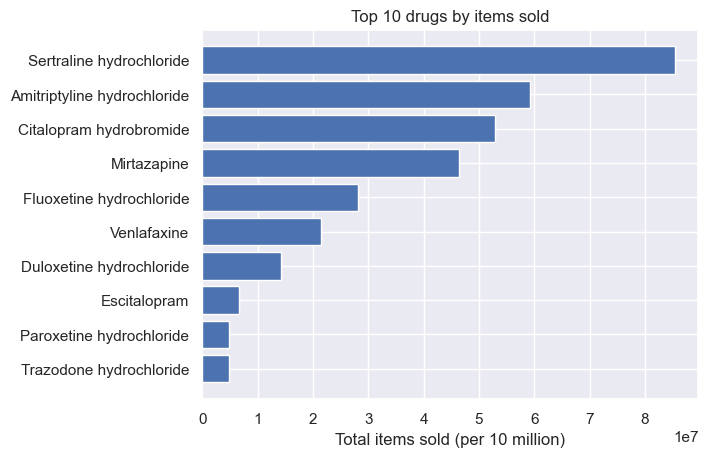

In [29]:
plt.barh(df_items["BNF_CHEMICAL_SUBSTANCE"].head(10), df_items["ITEMS"].head(10))
plt.xlabel("Total items sold (per 10 million)")
plt.title("Top 10 drugs by items sold")
plt.gca().invert_yaxis()
plt.show()

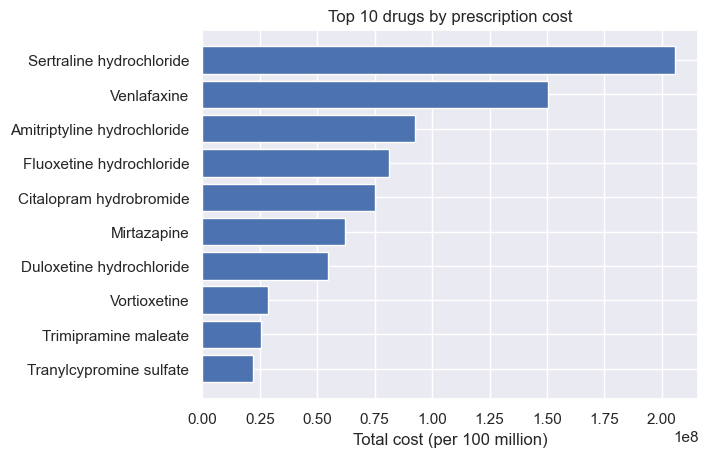

In [30]:
plt.barh(df_cost["BNF_CHEMICAL_SUBSTANCE"].head(10), df_cost["COST"].head(10))
plt.xlabel("Total cost (per 100 million)")
plt.title("Top 10 drugs by prescription cost")
plt.gca().invert_yaxis()
plt.show()

From the above two barcharts, we can make the following observations:

1. Sertraline hydrochloride	is the most selling drug item-wise as well as cost-wise. It's ahead of the drug at second-place by around 30% in terms of both items sold and prescribing cost.

2. Venlafaxine is at the second place in terms of prescribing cost but its not in the top-10 drugs sold item-wise. This suggests that it must be a costly drug. Similarly, other drugs which are present in the top-10 cost wise list but not present in the top-10 item wise list indicate that these drugs must be costly.

Let's analyse the price trends of these drugs over time

In [31]:
drugs = pca_regional_drug_summary_df["BNF_CHEMICAL_SUBSTANCE"].unique()
# drugs


In [32]:
df_cost_per_item = pca_regional_drug_summary_df.copy()
drug_cpi = {} # drug-wise cost per item over months
for drug in drugs:
    df_x = df_cost_per_item[df_cost_per_item["BNF_CHEMICAL_SUBSTANCE"] == drug]
    df_x_cost = df_x.groupby(by = "YEAR_MONTH", as_index=False)["COST"].sum()
    df_x_items = df_x.groupby(by = "YEAR_MONTH", as_index=False)["ITEMS"].sum()
    df_x = df_x_cost.merge(df_x_items, on = "YEAR_MONTH")
    df_x["CPI"] = df_x["COST"]/df_x["ITEMS"]
    df_x = df_x.sort_values("YEAR_MONTH", ascending=True)
    drug_cpi[drug] = df_x["CPI"]

In [33]:
year_month = np.sort(pca_regional_drug_summary_df.YEAR_MONTH.unique())

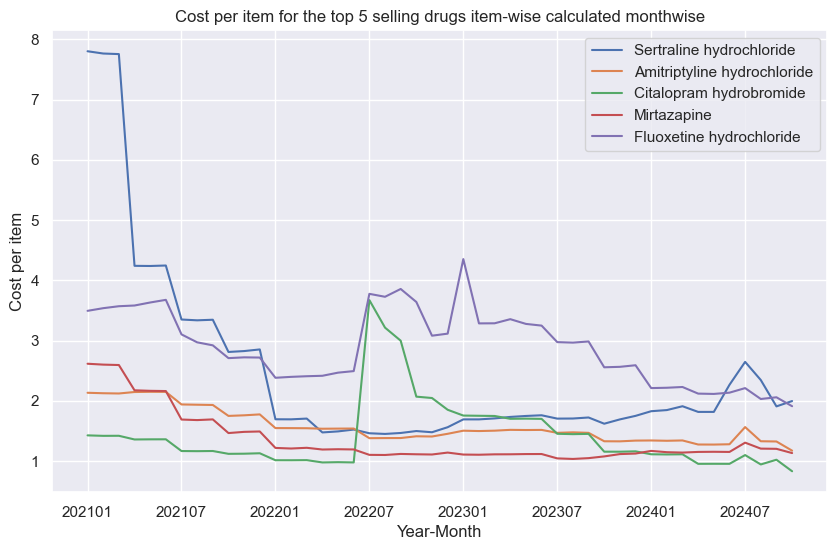

In [34]:
# Analysing the cost per item for the top 5 drugs sold item-wise

plt.figure(figsize=(10,6))
for drug in top_10_drugs_items[:5]:
    plt.plot(np.arange(len(drug_cpi[drug])), drug_cpi[drug], label = drug)
plt.xlabel("Year-Month")
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.ylabel("Cost per item")
plt.title("Cost per item for the top 5 selling drugs item-wise calculated monthwise")
plt.legend()
plt.show()



From this, we can see that there is a clear decreasing trend in the cost per item of top-5 most selling drugs overtime. This decrease has been the most prominent from Jan 2021 to Jan 2022. This decrease is a major reason for the decrease in average cost per drug item over-time, which we observed earlier.

#### Longitudinal Analysis


To supplement the initial analysis, we will now:

-   Look at the longitudinal (monthly) trend for all antidepressant items and for the cost of antidepressant prescribing
-   Then, explore the data and find the antidepressant drugs that are driving these monthly item and cost trends.
-   Then give a high-level summary to your work and findings.


In [35]:
# creating dataframe to analyse the cost and item sold of drugs over the months
df_cost_monthwise = pca_regional_drug_summary_df.pivot_table(columns = "BNF_CHEMICAL_SUBSTANCE", index="YEAR_MONTH", values="COST", aggfunc = sum)
df_items_monthwise = pca_regional_drug_summary_df.pivot_table(columns = "BNF_CHEMICAL_SUBSTANCE", index="YEAR_MONTH", values="ITEMS", aggfunc = sum)
# display(df_cost_monthwise.head())
# display(df_items_monthwise.head())

In [36]:
# imputing the nan values to zero
df_cost_monthwise.fillna(0, inplace=True)
df_items_monthwise.fillna(0, inplace=True)

Creating an average drug price chart to compare the average price of each anti-depressant 

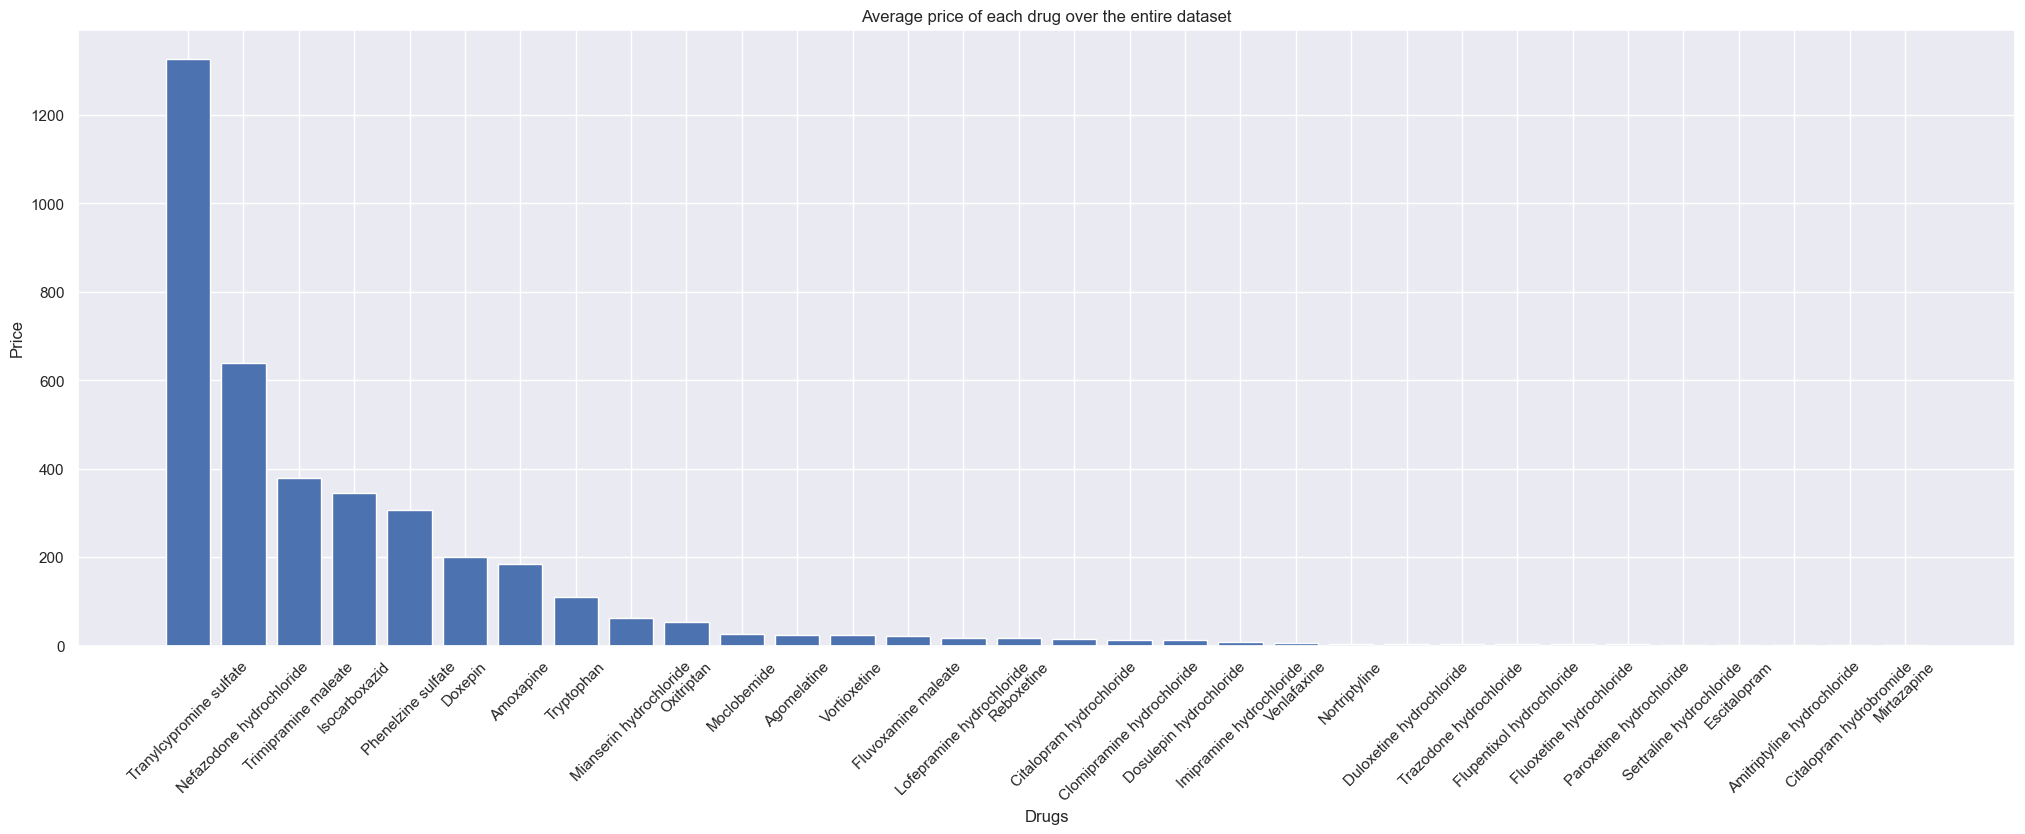

In [37]:
drug_avg_price = []
for drug in drugs:
    total_cost = df_cost_monthwise[drug].sum()
    total_items = df_items_monthwise[drug].sum()
    drug_avg_price.append((drug, total_cost/total_items))

drug_avg_price = sorted(drug_avg_price, key = lambda x: x[1], reverse=True)
plt.figure(figsize = (25,8))
plt.bar(np.arange(len(drugs)), [x[1] for x in drug_avg_price])
plt.xticks(np.arange(len(drugs)), [x[0] for x in drug_avg_price], rotation = 45)
plt.xlabel("Drugs")
plt.ylabel("Price")
plt.title("Average price of each drug over the entire dataset")
plt.show()

In [38]:
top_5_costliest = [x[0] for x in drug_avg_price[:5]]
top_5_cheapest = [x[0] for x in drug_avg_price[-5:]]

print(f"The top-5 most costliest anti-depressant drugs are: \n {top_5_costliest}")
print()
print(f"The top-5 cheapest anti-depressant drugs are: \n {top_5_cheapest}")

The top-5 most costliest anti-depressant drugs are: 
 ['Tranylcypromine sulfate', 'Nefazodone hydrochloride', 'Trimipramine maleate', 'Isocarboxazid', 'Phenelzine sulfate']

The top-5 cheapest anti-depressant drugs are: 
 ['Sertraline hydrochloride', 'Escitalopram', 'Amitriptyline hydrochloride', 'Citalopram hydrobromide', 'Mirtazapine']


In [39]:
topx = 5  # variable to take top x items as leading (can take value from 1 to 32)

topx_cost = df_cost.iloc[:topx, 0].values
topx_items = df_items.iloc[:topx, 0].values

df_topx_cost = {}
df_topx_items = {}

df_topx_cost["others"] = np.zeros(len(year_month))
df_topx_items["others"] = np.zeros(len(year_month))

for drug in df_cost_monthwise.columns.values:
    if drug in topx_cost:
        df_topx_cost[drug] = df_cost_monthwise[drug]
    else:
        df_topx_cost["others"] += df_cost_monthwise[drug]


for drug in df_items_monthwise.columns.values:
    if drug in topx_items:
        df_topx_items[drug] = df_items_monthwise[drug]
    else:
        df_topx_items["others"] += df_items_monthwise[drug]


df_topx_items = pd.DataFrame(df_topx_items)
df_topx_cost = pd.DataFrame(df_topx_cost)


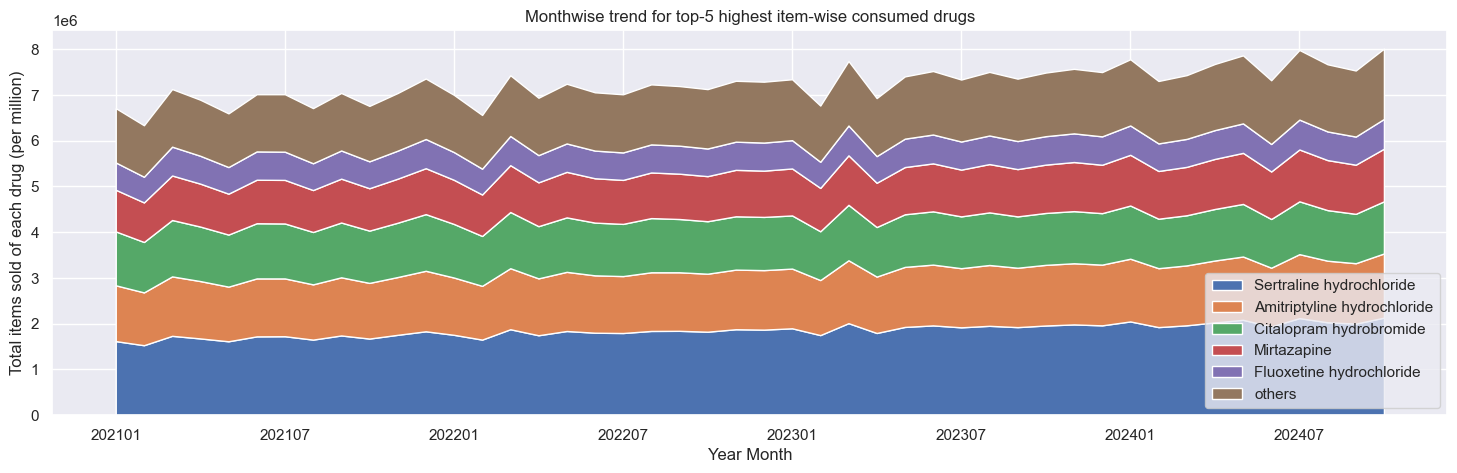

In [40]:
topx_cost_others = list(topx_cost.copy())
topx_cost_others.append("others")

topx_items_others = list(topx_items.copy())
topx_items_others.append("others")

# stackplot for top5_items drugs
plt.figure(figsize = (18,5))
plt.stackplot(np.arange(len(year_month)), [df_topx_items.loc[:, c].values for c in topx_items_others], labels=topx_items_others)
plt.legend()
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.xlabel("Year Month")
plt.ylabel("Total items sold of each drug (per million)")
plt.title("Monthwise trend for top-5 highest item-wise consumed drugs")
plt.show()

From the above chart, we can see that the top-3 drugs being sold item-wise ('Sertraline hydrochloride', 'Amitriptyline hydrochloride', and 'Citalopram hydrobromide') contribute to more than 50% of the total drugs sold item-wise. Therefore, the variation in the number of items sold for these drugs highly affects the changes in the overall trend and therefore we can say that they drive the overall trend.

On comparing with the bar chart showing the average cost of drugs that we compiled earlier, we can see that the top-5 most sold drugs are some of the cheapest drugs available. For example, Sertraline hydrochloride is the fifth cheapest drug, and Amitriptyline hydrochloride is the third cheapest drug. From this, we can conclude that a majority of the drugs which are being sold are comparatively cheaper. This is a good stat to know.

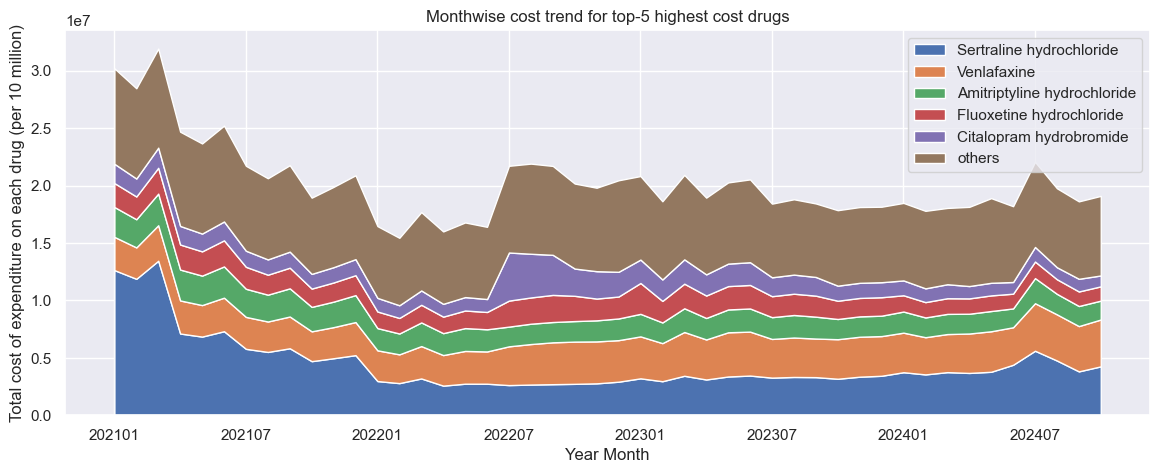

In [41]:
# stackplot for top5_cost drugs
plt.figure(figsize = (14,5))
plt.stackplot(np.arange(len(year_month)), [df_topx_cost.loc[:, c].values for c in topx_cost_others], labels=topx_cost_others)
plt.legend()
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.xlabel("Year Month")
plt.ylabel("Total cost of expenditure on each drug (per 10 million)")
plt.title("Monthwise cost trend for top-5 highest cost drugs")
plt.show()

From this chart, we can see that cost-wise, the top-3 drugs contribute to more than 50% of the prescription cost of total drugs being sold. Therefore, we can say that the top-3 drugs are the drivers of the overall trend for prescription cost on these drugs.

Also, similar to the top-5 most sold drugs item-wise, these drugs are also comparatively much cheaper than other durgs. Therefore, we can say that the reason for these drugs to have such huge prescription cost is not due to their high price, but due to their high volumes being sold.

On combining the observations from the above two stacked plots with price trends for the top-5 most sold drugs item-wise (chart reproduced below), we can explain some of the trends that we observe:

1. The decrease in the total cost from Jan 2021 to Jan 2022 is mainly due to the decrease in the price of Sertraline hydrochloride. This is obvious from the significant decline in the cost of Sertraline hydrochloride as observed from the chart below.

2. The jump in the total cost around July 2022 is mainly due to the sudden increase in the price of Citalopram hydrobromide and Fluoxetine hydrochloride drugs. These drugs are in the top-5 most sold drugs item-wise and an increase in their price is bound to increase the total prescription cost of drugs.

3. Similarly to previous point, the peak in overall prescription cost on drugs during July 2024 is mainly due to a sudden increase in the average price of Sertraline hydrochloride.

PS: Venlafaxine is the sixth most sold drug item-wise

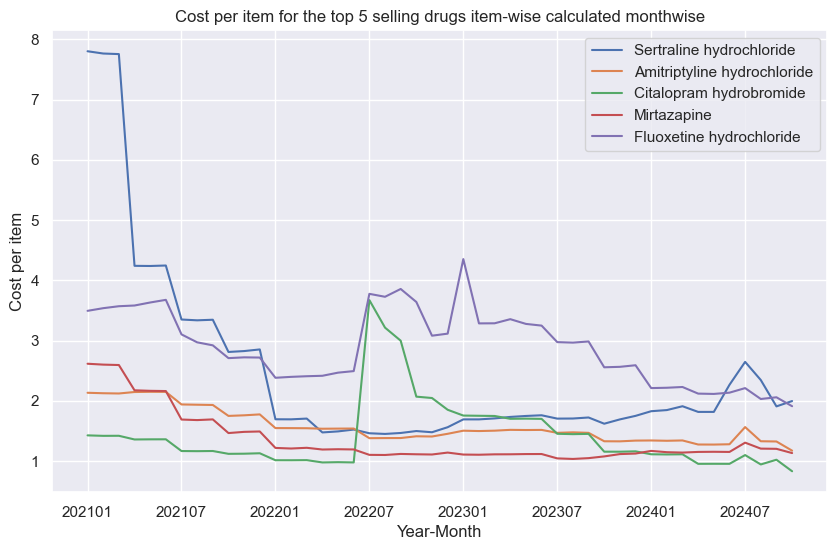

In [42]:
# Reproducing cost per item trend for the top-5 selling drugs

plt.figure(figsize=(10,6))
for drug in top_10_drugs_items[:5]:
    plt.plot(np.arange(len(drug_cpi[drug])), drug_cpi[drug], label = drug)
plt.xlabel("Year-Month")
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.ylabel("Cost per item")
plt.title("Cost per item for the top 5 selling drugs item-wise calculated monthwise")
plt.legend()
plt.show()

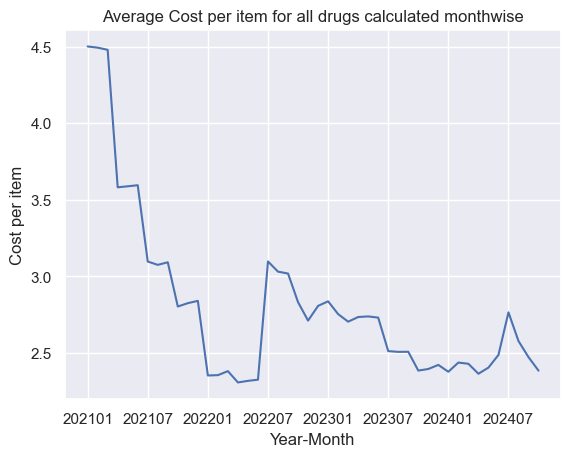

In [43]:
cpi_trend = df_cost_monthwise.sum(axis = 1).values/df_items_monthwise.sum(axis = 1).values
plt.plot(cpi_trend)
plt.xlabel("Year-Month")
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.ylabel("Cost per item")
plt.title("Average Cost per item for all drugs calculated monthwise")
plt.show()

#### Summary

•	Sales Volume & Pricing: The top-3 most sold drugs (‘Sertraline hydrochloride’, ‘Amitriptyline hydrochloride’, ‘Citalopram hydrobromide’) account for over 50% of total sales, indicating that overall market trends are largely driven by their sales fluctuations.

•	Prescription Cost Drivers: Despite being inexpensive, these high-volume drugs contribute significantly to total prescription costs, meaning prescription cost trends are volume-driven rather than price-driven.

#### Antidepressant Case study: Sertraline hydrochloride

We will now do a case study on Sertraline hydrochloride to perform the following tasks:

-   Focus one one or more antidepressants that play a significant role in national volume and cost trends
-   Percentage of total antidepressant volume or cost from a drug
-   Mean cost per item in relation a drug
-   Distribution of mean cost per item values for a drug
-   Anything else you think might be informative or relevant (be creative!)
-   Then give a high-level summary to your work and findings.



#### Calculating percentage of Sertraline hydrochloride item wise and cost wise with respect to the rest of the drugs

In [44]:
sh_cost_percent = df_cost_monthwise.loc[:, "Sertraline hydrochloride"]/df_cost_monthwise.sum(axis=1)*100
sh_items_percent = df_items_monthwise.loc[:, "Sertraline hydrochloride"]/df_items_monthwise.sum(axis=1)*100

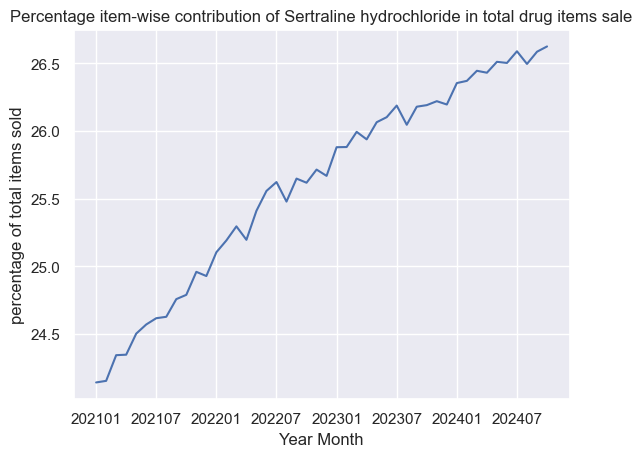

In [45]:
plt.plot(np.arange(len(year_month)), sh_items_percent)
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.xlabel("Year Month")
plt.ylabel("percentage of total items sold")
plt.title("Percentage item-wise contribution of Sertraline hydrochloride in total drug items sale")
plt.show()

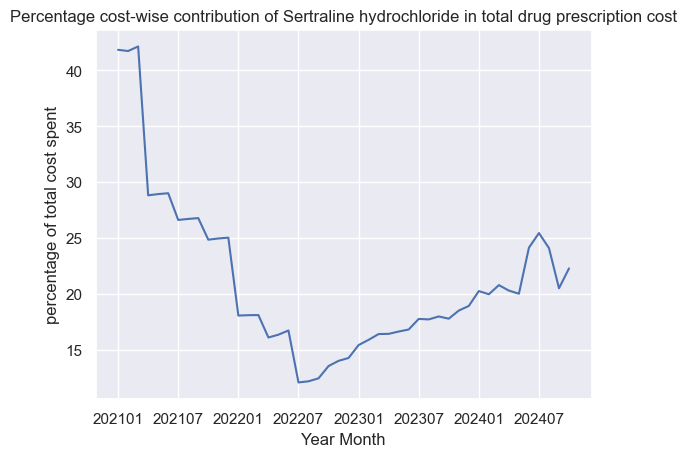

In [46]:
plt.plot(np.arange(len(year_month)), sh_cost_percent)
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.xlabel("Year Month")
plt.ylabel("percentage of total cost spent")
plt.title("Percentage cost-wise contribution of Sertraline hydrochloride in total drug prescription cost")
plt.show()

The item wise percentage contribution of Sertraline hydrochloride has a clear increasing trend, showing that it's remained the most prescribed drug throughout the entire time period. Therefore, it is safe to say that the variation in the prescription cost-wise contribution of Sertraline hydrochloride is due to changes in the price of Sertraline hydrochloride. When the price of Sertraline hydrochloride decreases, it's contribution to the total prescription cost also decreases, and vice-versa.

In [47]:
drug_avg_price_dict = dict(drug_avg_price)
# drug_avg_price_dict["Sertraline hydrochloride"]

The average price of Sertraline hydrochloride over the entire time-period is 2.408 per item.

#### Distribution of mean price per item for Sertraline hydrochloride calculated month-wise

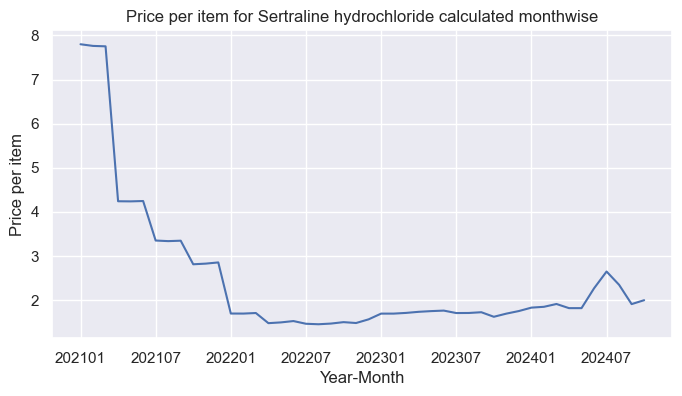

In [48]:
plt.figure(figsize=(8,4))
for drug in top_10_drugs_items[:1]:
    plt.plot(np.arange(len(drug_cpi[drug])), drug_cpi[drug], label = drug)
plt.xlabel("Year-Month")
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.ylabel("Price per item")
plt.title("Price per item for Sertraline hydrochloride calculated monthwise")
plt.show()

The price per item of Sertraline hydrochloride shows an overall decreasing trend. This means that the average price of Sertraline hydrochloride has been decreasing over the given time-period from Jan 2021 to Oct 2024. This is a good thing since it's the most sold drug.

#### Doing a region-wise analysis of average price of Sertraline hydrochloride

In [49]:
df_sh = pca_regional_drug_summary_df[pca_regional_drug_summary_df["BNF_CHEMICAL_SUBSTANCE"] == "Sertraline hydrochloride"]
df_sh["CPI"] = df_sh["COST"]/df_sh["ITEMS"]
df_sh_pivot = df_sh.pivot_table(columns = "REGION_NAME", index="YEAR_MONTH", values="CPI")
# df_sh_pivot.head()

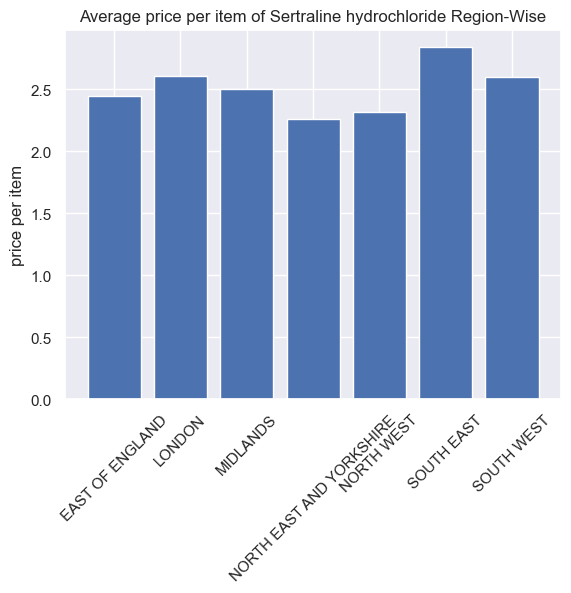

In [50]:
avg_cpi_sh_regionwise = df_sh_pivot.describe().loc["mean", :]
plt.bar(np.arange(len(avg_cpi_sh_regionwise)), avg_cpi_sh_regionwise.values)
plt.xticks(np.arange(len(avg_cpi_sh_regionwise)), df_sh_pivot.columns, rotation = 45)
plt.ylabel("price per item")
plt.title("Average price per item of Sertraline hydrochloride Region-Wise")
plt.show()

From the above bar-chart, we can see that the average price of Sertraline hydrochloride per item over the entire time period is highest in the South East region and lowest in the North East and Yorkshire region. The reason for this difference in price can be further analysed, considering that Sertraline hydrochloride is a highly prescribed drug.

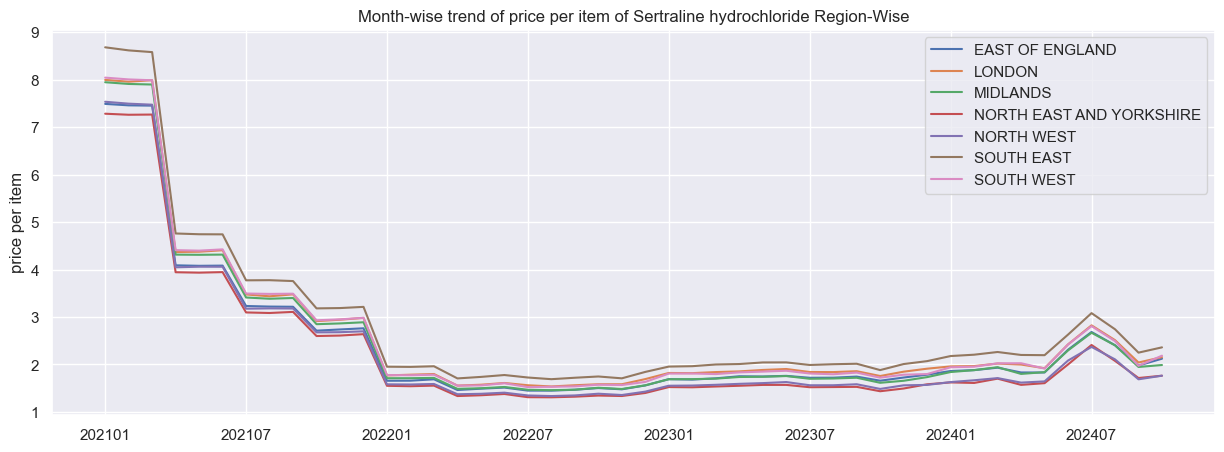

In [51]:
plt.figure(figsize=(15,5))
plt.plot(np.arange(len(year_month)), df_sh_pivot, label = df_sh_pivot.columns)
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.ylabel("price per item")
plt.title("Month-wise trend of price per item of Sertraline hydrochloride Region-Wise")
plt.legend()
plt.show()

The variation in average price per item of Sertraline hydrochloride calculated month-wise for different regions. This trend shows that even though there is a difference in the price of Sertraline hydrochloride in different regions, it's price in different regions follows a similar trend over time, indicating that they are all affected by common factors.

#### Forecasting the items being sold for Sertraline hydrochloride


Now, we will try to forecast the items being sold for Sertraline hydrochloride anti-depressant drug for the next 4 months using linear regression. We will use sklearn library for implementing linear regression.

In [52]:
sh_items_monthwise = df_items_monthwise.loc[:, "Sertraline hydrochloride"].values

from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(np.arange(len(year_month)).reshape(-1, 1), sh_items_monthwise)

LinearRegression()

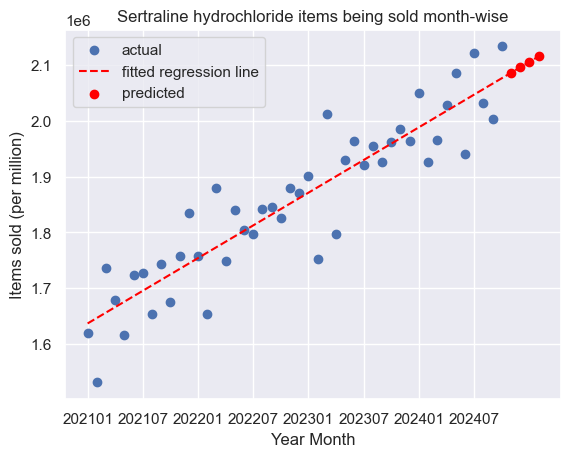

In [53]:
plt.scatter(np.arange(len(year_month)), sh_items_monthwise, label = "actual")
plt.plot(np.arange(len(year_month)+4), linreg.coef_*np.arange(len(year_month)+4) + linreg.intercept_, linestyle = "--", color = "red", label = "fitted regression line")
plt.scatter(np.arange(len(year_month), len(year_month)+4), linreg.coef_*np.arange(len(year_month), len(year_month)+4) + linreg.intercept_, color = "red", label = "predicted")
plt.title("Sertraline hydrochloride items being sold month-wise")
plt.xticks(np.arange(len(year_month))[::6], year_month[::6])
plt.xlabel("Year Month")
plt.ylabel("Items sold (per million)")
plt.legend()
plt.show()

#### Summary


Key insights include:

•	Consistent Dominance: Sertraline hydrochloride’s percentage contribution to total prescriptions has steadily increased, reinforcing its role as the most widely used antidepressant.

•	Price Trends: The drug’s price per item has shown a consistent decline from Jan 2021 to Oct 2024, which is beneficial given its high prescription volume. The overall average price per item across the period is 2.408.

•	Regional Price Variation: Prices are highest in the South East and lowest in North East and Yorkshire, suggesting potential regional pricing factors worth further investigation.

•	Common Price Trends Across Regions: Despite regional price variations, all regions exhibit a similar price trend over time, indicating that common external factors influence pricing across different areas.